In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
import os

fifa_ranking_2022 = pd.read_csv('fifa_ranking_2022-10-06.csv')

fifa_ranking_2026 = pd.read_csv('fifa_ranking_2026-06-08.csv')

matches = pd.read_csv('matches_1930_2022.csv')

schedule_2026 = pd.read_csv('schedule_2026.csv')

world_cup = pd.read_csv('world_cup.csv')

print("Successfully loaded all datasets.")

from sklearn.linear_model import LogisticRegression
import inspect

print(inspect.signature(LogisticRegression))


Successfully loaded all datasets.
(penalty='deprecated', *, C=1.0, l1_ratio=0.0, dual=False, tol=0.0001, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, verbose=0, warm_start=False, n_jobs=None)


In [184]:
# Display the first few rows of each dataset
print("FIFA Ranking 2022:")
print(fifa_ranking_2022.head().to_string(index=False))

print("\nFIFA Ranking 2026:")
print(fifa_ranking_2026.head().to_string(index=False))

print("\nMatches 1930-2022:")
print(matches.head().to_string(index=False))

print("\nMatches 2026:")
print(schedule_2026.head().to_string(index=False))

print("\nWorld Cup History:")
print(world_cup.head().to_string(index=False))

FIFA Ranking 2022:
     team team_code association  rank  previous_rank  points  previous_points
   Brazil       BRA    CONMEBOL     1              1 1841.30          1837.56
  Belgium       BEL        UEFA     2              2 1816.71          1821.92
Argentina       ARG    CONMEBOL     3              3 1773.88          1770.65
   France       FRA        UEFA     4              4 1759.78          1764.85
  England       ENG        UEFA     5              5 1728.47          1737.46

FIFA Ranking 2026:
     team team_code association  rank  previous_rank      points  previous_points  rated_matches
Argentina       ARG    CONMEBOL     1              3 1876.118331      1874.814835             59
    Spain       ESP        UEFA     2              2 1873.013187      1876.395199             56
   France       FRA        UEFA     3              1 1869.428449      1877.322731             57
  England       ENG        UEFA     4              4 1827.048678      1825.965482             57
 Portuga

In [185]:
schedule_2026_missing_val = schedule_2026.isnull().sum()
fifa_ranking_2022_missing_val = fifa_ranking_2022.isnull().sum()
fifa_ranking_2026_missing_val = fifa_ranking_2026.isnull().sum()
matches_missing_val = matches.isnull().sum()
world_cup_missing_val = matches.isnull().sum()
missing_total = schedule_2026_missing_val + fifa_ranking_2022_missing_val + fifa_ranking_2026_missing_val + matches_missing_val + world_cup_missing_val

print("Display missing values in all data files.")
print(missing_total)

# Filling missing values with 0
schedule_2026 = schedule_2026.fillna(0)
fifa_ranking_2022 = fifa_ranking_2022.fillna(0)
fifa_ranking_2026 = fifa_ranking_2026.fillna(0)
matches = matches.fillna(0)
world_cup = world_cup.fillna(0)


team_mapping = {
    "United States" : "USA",
    "Bosnia-Herzegovina" : "Bosnia and Herzegovina",
    "Congo DR" : "Congo"
}

schedule_2026['home_team'] = schedule_2026["home_team"].replace(team_mapping)
schedule_2026['away_team'] = schedule_2026["away_team"].replace(team_mapping)
matches['home_team'] = matches["home_team"].replace(team_mapping)
matches['away_team'] = matches["away_team"].replace(team_mapping)


Display missing values in all data files.
Attendance                        NaN
Date                              NaN
Day                               NaN
Host                              NaN
Notes                             NaN
Officials                         NaN
Referee                           NaN
Round                             NaN
Score                             NaN
Time                              NaN
Venue                             NaN
Year                              NaN
association                       NaN
away_captain                      NaN
away_goal                         NaN
away_goal_long                    NaN
away_manager                      NaN
away_own_goal                     NaN
away_penalty                      NaN
away_penalty_goal                 NaN
away_penalty_miss_long            NaN
away_penalty_shootout_goal_long   NaN
away_penalty_shootout_miss_long   NaN
away_red_card                     NaN
away_score                        NaN
away_sub

In [186]:
merge_ranking = pd.merge(fifa_ranking_2026, fifa_ranking_2022, on='team', suffixes=('_2026', '_2022'))

merge_ranking['rank_change'] = merge_ranking['rank_2022'] - merge_ranking['rank_2026']

# Display the merged ranking
print(merge_ranking[['team', 'rank_2022', 'rank_2026', 'rank_change']].head().to_string(index=False))

     team  rank_2022  rank_2026  rank_change
Argentina          3          1            2
    Spain          7          2            5
   France          4          3            1
  England          5          4            1
 Portugal          9          5            4


World Cup Data Head.
 Year         Host  Teams  Champion   Runner-Up                            TopScorrer  Attendance  AttendanceAvg  Matches
 2022        Qatar     32 Argentina      France                     Kylian Mbappé - 8     3404252          53191       64
 2018       Russia     32    France     Croatia                        Harry Kane - 6     3031768          47371       64
 2014       Brazil     32   Germany   Argentina                   James Rodríguez - 6     3429873          53592       64
 2010 South Africa     32     Spain Netherlands Wesley Sneijder, Thomas Müller... - 5     3178856          49670       64
 2006      Germany     32     Italy      France                    Miroslav Klose - 5     3352605          52384       64

World Cup Champions Frequency
       Champion  Count                            Year
0        Brazil      5  [1958, 1962, 1970, 1994, 2002]
1         Italy      4        [1934, 1938, 1982, 2006]
2     Argentina      3              [1978, 1986, 20

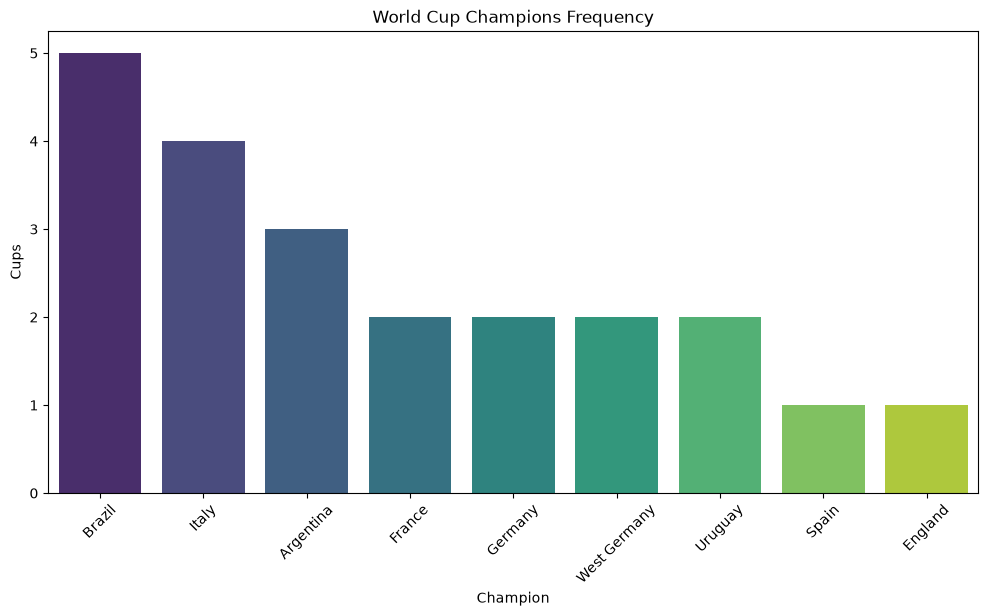

In [187]:
# World Cup summary
print('World Cup Data Head.')
print(world_cup.head().to_string(index=False))

# Display Championship
champion_table = world_cup.groupby('Champion')['Year'].apply(lambda x: sorted(x))
champion_table = champion_table.reset_index()
champion_table['Count'] = champion_table['Year'].apply(len)
champion_table = champion_table.sort_values('Count', ascending=False)[['Champion', 'Count', 'Year']]
champion_table = champion_table.reset_index(drop=True)

print("\nWorld Cup Champions Frequency")
print(champion_table)

champion_counts = world_cup['Champion'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=champion_counts.index, y=champion_counts.values, hue=champion_counts.index, palette='viridis', legend=False)
plt.title('World Cup Champions Frequency')
plt.xticks(rotation=45)
plt.xlabel('Champion')
plt.ylabel('Cups')
plt.show()

Display match dataset Date column info, after modifying.
count                           964
mean     1989-09-28 05:07:43.070539
min             1930-07-13 00:00:00
25%             1974-06-18 00:00:00
50%             1994-06-24 00:00:00
75%             2010-06-16 00:00:00
max             2022-12-18 00:00:00
Name: Date, dtype: object


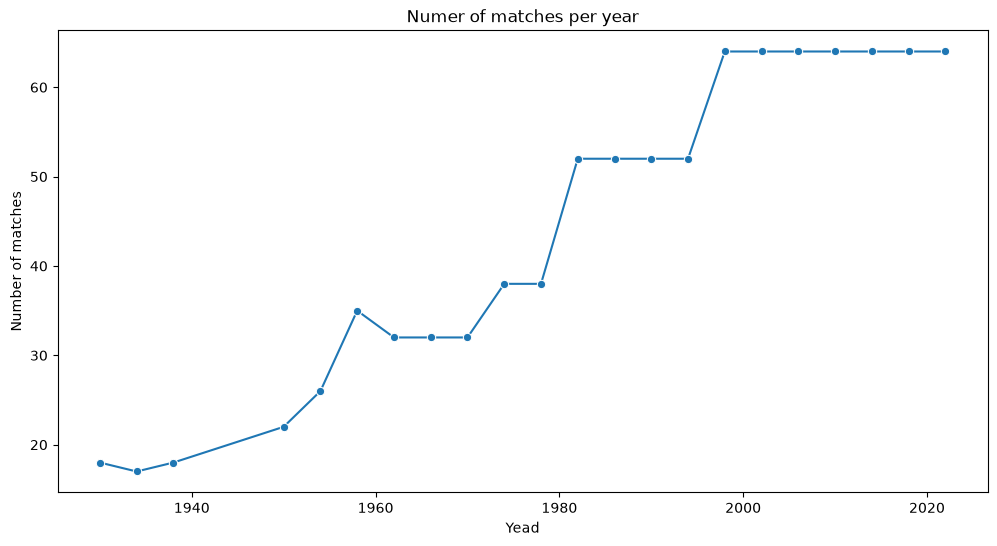

In [188]:
matches['Date'] = pd.to_datetime(matches['Date'], errors='coerce')
matches = matches.sort_values('Date').reset_index(drop=True)
print("Display match dataset Date column info, after modifying.")
print(matches['Date'].describe())

# Display mathces per year
matches_per_year = matches.groupby('Year').size()
plt.figure(figsize=(12,6))
sns.lineplot(x=matches_per_year.index, y=matches_per_year.values, marker='o')
plt.title('Numer of matches per year')
plt.xlabel('Yead')
plt.ylabel('Number of matches')
plt.show()

Date schedules 2026 after modifying.
count                     72
mean     2026-06-20 03:20:00
min      2026-06-11 00:00:00
25%      2026-06-16 00:00:00
50%      2026-06-20 12:00:00
75%      2026-06-24 06:00:00
max      2026-06-27 00:00:00
Name: Date, dtype: object

Schedule 2026 head.
      Round Day       Date          Time  Score  Referee  Notes  Year      home_team              away_team
Group stage Thu 2026-06-11 13:00 (22:00)    0.0      0.0    0.0  2026         Mexico           South Africa
Group stage Thu 2026-06-11 20:00 (05:00)    0.0      0.0    0.0  2026 Korea Republic                Czechia
Group stage Fri 2026-06-12 15:00 (22:00)    0.0      0.0    0.0  2026         Canada Bosnia and Herzegovina
Group stage Fri 2026-06-12 18:00 (04:00)    0.0      0.0    0.0  2026            USA               Paraguay
Group stage Sat 2026-06-13 12:00 (22:00)    0.0      0.0    0.0  2026          Qatar            Switzerland


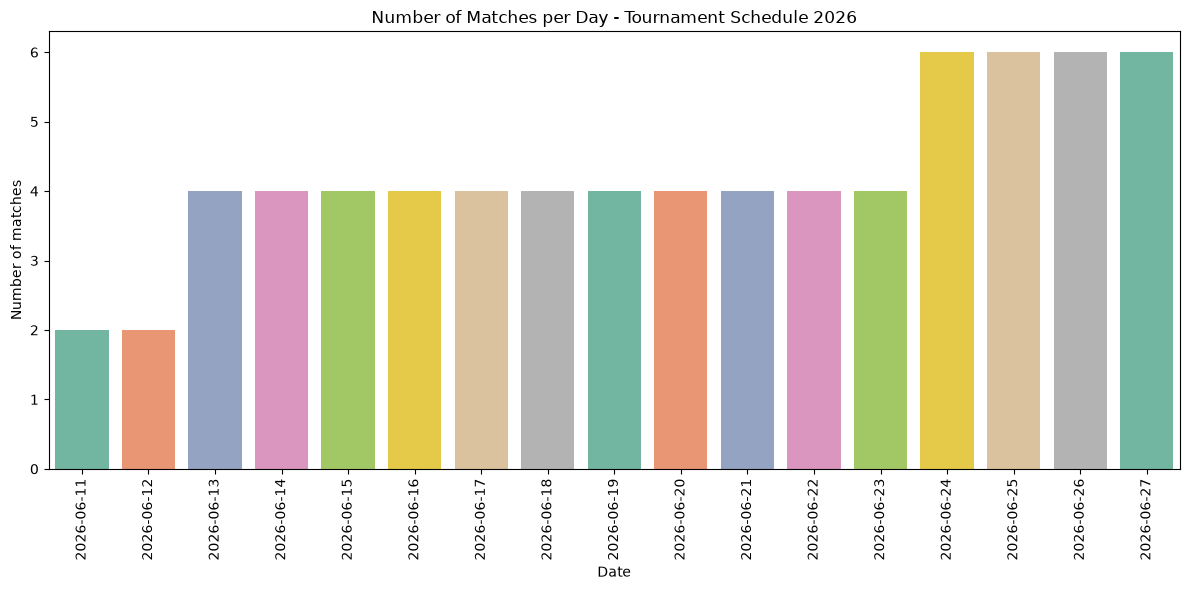

In [189]:
schedule_2026['Date'] = pd.to_datetime(schedule_2026['Date'], errors='coerce')
print("Date schedules 2026 after modifying.")
print(schedule_2026['Date'].describe())

print("\nSchedule 2026 head.")
print(schedule_2026.head().to_string(index=False))

plt.figure(figsize=(12,6))
sns.countplot(data=schedule_2026, x='Date', palette='Set2', order=sorted(schedule_2026['Date'].unique()), hue='Date', legend=False)
plt.title("Number of Matches per Day - Tournament Schedule 2026")
plt.xlabel('Date')
plt.ylabel('Number of matches')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [190]:
def get_result(row):
    if row['home_score'] > row['away_score']:
        return "Home" # Home team win
    elif row['home_score'] < row['away_score']:
        return "Away" # Away team win
    else:
        return "Draw" # Draw

matches['result'] = matches.apply(get_result, axis=1)

home_rankings = fifa_ranking_2022[[
    "team",
    "rank",
    "points"
]].rename(columns={
    "team": "home_team",
    "rank": "home_rank",
    "points": "home_points"
})

away_rankings = fifa_ranking_2022[[
    "team",
    "rank",
    "points"
]].rename(columns={
    "team": "away_team",
    "rank": "away_rank",
    "points": "away_points"
})

matches = matches.merge(
    home_rankings,
    on='home_team',
    how='left'
)

matches = matches.merge(
    away_rankings,
    on='away_team',
    how='left'
)

matches['rank_diff'] = (
    matches['home_rank']
    - matches['away_rank']
)

matches['points_diff'] = (
    matches['home_points']
    - matches['away_points']
)

matches['strength_gap'] = abs(
    matches['home_points'] - matches['away_points']
)

matches['elo_prob_home'] = 1 / (
    1 + 10 ** ((matches['away_points'] - matches['home_points']) / 400)
)

matches['rank_gap_abs'] = abs(matches['rank_diff'])

matches['points_gap_abs'] = abs(matches['points_diff'])

matches = matches.fillna(0)

In [191]:
matches["Date"] = pd.to_datetime(matches["Date"])

matches = (
    matches
    .sort_values("Date")
    .reset_index(drop=True)
)

team_history = defaultdict(list)

matches['home_last5_win_rate'] = 0.0
matches['away_last5_win_rate'] = 0.0

matches['home_last5_goals_for'] = 0.0
matches['away_last5_goals_for'] = 0.0

matches['home_last5_goals_against'] = 0.0
matches['away_last5_goals_against'] = 0.0

matches["home_last5_draw_rate"] = 0.0
matches["away_last5_draw_rate"] = 0.0

for idx, row in matches.iterrows():

    home = row['home_team']
    away = row['away_team']

    home_history = team_history[home][-5:]
    away_history = team_history[away][-5:]

    if home_history:

        matches.loc[idx, 'home_last5_win_rate'] = np.mean(
            [m['win'] for m in home_history]
        )

        matches.loc[idx, 'home_last5_goals_for'] = np.mean(
            [m['goals_for'] for m in home_history]
        )

        matches.loc[idx, 'home_last5_goals_against'] = np.mean(
            [m['goals_against'] for m in home_history]
        )

        matches.loc[idx, "home_last5_draw_rate"] = np.mean(
            [m["draw"] for m in home_history]
        )
    
    if away_history:

        matches.loc[idx, 'away_last5_win_rate'] = np.mean(
            [m['win'] for m in away_history]
        )

        matches.loc[idx, 'away_last5_goals_for'] = np.mean(
            [m['goals_for'] for m in away_history]
        )

        matches.loc[idx, 'away_last5_goals_against'] = np.mean(
            [m['goals_against'] for m in away_history]
        )
        
        matches.loc[idx, "away_last5_draw_rate"] = np.mean(
            [m["draw"] for m in away_history]
        )

    home_win = int(row['home_score'] > row['away_score'])
    away_win = int(row['away_score'] > row['home_score'])

    team_history[home].append({
    "win": home_win,
    "draw": int(row["home_score"] == row["away_score"]),
    "goals_for": row["home_score"],
    "goals_against": row["away_score"]
    })

    team_history[away].append({
    "win": away_win,
    "draw": int(row["away_score"] == row["home_score"]),
    "goals_for": row["away_score"],
    "goals_against": row["home_score"]
    })

matches['form_diff'] = (
    matches['home_last5_win_rate']
    - matches['away_last5_win_rate']
)

matches['attack_diff'] = (
    matches['home_last5_goals_for']
    - matches['away_last5_goals_for']
)

matches['defense_diff'] = (
    matches['away_last5_goals_against']
    - matches['home_last5_goals_against']
)

matches["draw_rate_diff"] = (
    matches["home_last5_draw_rate"]
    - matches["away_last5_draw_rate"]
)

matches["home_advantage"] = (
    matches["Host"] == matches["home_team"]
).astype(int)

print(matches[[
    "home_team",
    "away_team",
    "home_rank",
    "away_rank",
    "home_score",
    "away_score", 
    "home_points",
    "away_points",
    "result",
    "rank_diff",
    "points_diff",
    "strength_gap",
    "elo_prob_home",
    "rank_gap_abs",
    "points_gap_abs",
    "home_last5_win_rate",
    "away_last5_win_rate",
    "home_last5_goals_for",
    "away_last5_goals_for",
    "home_last5_goals_against",
    "away_last5_goals_against",
    "home_last5_draw_rate",
    "away_last5_draw_rate",
    "form_diff",
    "attack_diff",
    "defense_diff",
    "draw_rate_diff",
    "home_advantage"
]].head().to_string(index=False))

 home_team away_team  home_rank  away_rank  home_score  away_score  home_points  away_points result  rank_diff  points_diff  strength_gap  elo_prob_home  rank_gap_abs  points_gap_abs  home_last5_win_rate  away_last5_win_rate  home_last5_goals_for  away_last5_goals_for  home_last5_goals_against  away_last5_goals_against  home_last5_draw_rate  away_last5_draw_rate  form_diff  attack_diff  defense_diff  draw_rate_diff  home_advantage
    France    Mexico        4.0       13.0           4           1      1759.78      1644.89   Home       -9.0       114.89        114.89       0.659566           9.0          114.89                  0.0                  0.0                   0.0                   0.0                       0.0                       0.0                   0.0                   0.0        0.0          0.0           0.0             0.0               0
       USA   Belgium       16.0        2.0           3           0      1627.48      1816.71   Home       14.0      -189.23       

In [192]:
scaler = StandardScaler()
feature = [
    'rank_diff',
    'points_diff',
    'strength_gap',
    'elo_prob_home',
    'rank_gap_abs',
    'points_gap_abs',

    'home_last5_win_rate',
    'away_last5_win_rate',
    'home_last5_draw_rate',
    'away_last5_draw_rate',

    'home_last5_goals_for',
    'away_last5_goals_for',

    'home_last5_goals_against',
    'away_last5_goals_against',

    'form_diff',
    'attack_diff',
    'defense_diff',

    'draw_rate_diff',
    'home_advantage'
]

X = matches[feature]
y = matches['result']

split = int(len(matches) * 0.8)

train = matches.iloc[:split]
test = matches.iloc[split:]

X_train = train[feature]
y_train = train["result"]

X_test = test[feature]
y_test = test["result"]

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

prediction = model.predict(X_test)
accuracy_score = accuracy_score(y_test, prediction)

print(classification_report(
    y_test,
    prediction
))
# print(matches['result'].value_counts(normalize=True))
# print(confusion_matrix(y_test, prediction))
# print(pd.crosstab(
#     y_test,
#     prediction,
#     rownames=['Actual'],
#     colnames=['Predicted']
# ))



              precision    recall  f1-score   support

        Away       0.52      0.64      0.58        69
        Draw       0.25      0.32      0.28        41
        Home       0.59      0.41      0.48        83

    accuracy                           0.47       193
   macro avg       0.45      0.45      0.45       193
weighted avg       0.49      0.47      0.47       193



In [193]:
modelForest = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)
modelForest.fit(X_train, y_train)
importance = pd.DataFrame({
    "Feature": feature,
    "Importance": modelForest.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print(importance.to_string(index=False))

                 Feature  Importance
             attack_diff    0.072876
    home_last5_goals_for    0.070826
            defense_diff    0.069667
             points_diff    0.067748
home_last5_goals_against    0.067000
    away_last5_goals_for    0.064745
away_last5_goals_against    0.064561
               rank_diff    0.063074
           elo_prob_home    0.061612
            strength_gap    0.054885
          points_gap_abs    0.053195
            rank_gap_abs    0.050916
               form_diff    0.047976
          draw_rate_diff    0.043160
     away_last5_win_rate    0.037129
     home_last5_win_rate    0.034877
    away_last5_draw_rate    0.034382
    home_last5_draw_rate    0.031282
          home_advantage    0.010089
